Connect to Drive

In [1]:

from google.colab import drive
drive.mount('/content/drive')

import os, json, time
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = '/content/drive/MyDrive/Projects/multi-agent-discovery'
DATA = os.path.join(PROJECT_ROOT, 'data/raw/ml-32m')
FIG  = os.path.join(PROJECT_ROOT, 'figures')
print("Project root:", PROJECT_ROOT, "| exists:", os.path.exists(PROJECT_ROOT))


Mounted at /content/drive
Project root: /content/drive/MyDrive/Projects/multi-agent-discovery | exists: True


MovielenS EDA

1. Load the small files, then load ratings with memory control

In [2]:
movies = pd.read_csv(os.path.join(DATA, 'movies.csv'))
links  = pd.read_csv(os.path.join(DATA, 'links.csv'))
print("movies:", movies.shape, "| links:", links.shape)

ratings = pd.read_csv(
    os.path.join(DATA, 'ratings.csv'),
    usecols=['userId', 'movieId', 'rating'],                              # skip timestamp
    dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'},   # downcast
)
print("ratings:", ratings.shape,
      "| memory:", round(ratings.memory_usage(deep=True).sum()/1e6, 1), "MB")

movies: (87585, 3) | links: (87585, 3)
ratings: (32000204, 3) | memory: 384.0 MB


2. Rating distribution

rating
0.5     525132
1.0     946675
1.5     531063
2.0    2028622
2.5    1685386
3.0    6054990
3.5    4290105
4.0    8367654
4.5    2974000
5.0    4596577
Name: count, dtype: int64


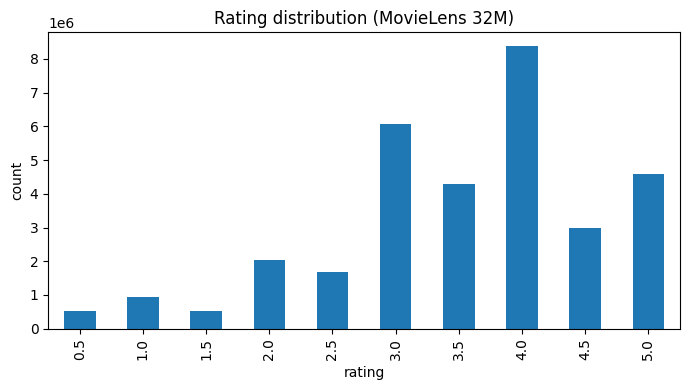

In [3]:
dist = ratings['rating'].value_counts().sort_index()
print(dist)

plt.figure(figsize=(7,4))
dist.plot(kind='bar')
plt.title('Rating distribution (MovieLens 32M)'); plt.xlabel('rating'); plt.ylabel('count')
plt.tight_layout()
os.makedirs(FIG, exist_ok=True)
plt.savefig(os.path.join(FIG, 'eda_rating_distribution.png'), dpi=120)
plt.show()

3. Sparsity

In [5]:
n_users   = ratings['userId'].nunique()
n_movies  = ratings['movieId'].nunique()
n_ratings = len(ratings)

density  = n_ratings / (n_users * n_movies)
print(f"users in ratings : {n_users:,}")
print(f"movies in ratings: {n_movies:,}")
print(f"total ratings    : {n_ratings:,}")
print(f"full matrix cells: {n_users * n_movies:,}")
print(f"density          : {density*100:.4f}%")
print(f"sparsity         : {(1-density)*100:.4f}%")

users in ratings : 200,948
movies in ratings: 84,432
total ratings    : 32,000,204
full matrix cells: 16,966,441,536
density          : 0.1886%
sparsity         : 99.8114%


4. Movie popularity long tail

count     84432.000000
mean        379.005638
std        2592.439791
min           1.000000
25%           2.000000
50%           5.000000
75%          25.000000
max      102929.000000
dtype: float64 

movies with >=    1 ratings: 84,432  (100.0%)
movies with >=    5 ratings: 43,884  (52.0%)
movies with >=   20 ratings: 23,350  (27.7%)
movies with >=   50 ratings: 16,034  (19.0%)
movies with >=  100 ratings: 12,191  (14.4%)
movies with >= 1000 ratings: 4,397  (5.2%)


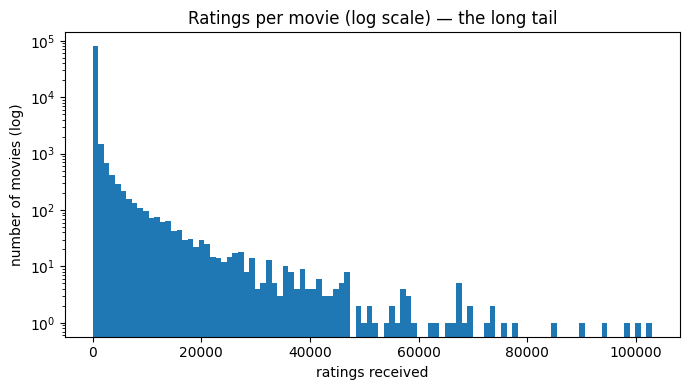

In [6]:
movie_counts = ratings.groupby('movieId').size()
print(movie_counts.describe(), "\n")
for thr in [1, 5, 20, 50, 100, 1000]:
    n = (movie_counts >= thr).sum()
    print(f"movies with >= {thr:>4} ratings: {n:,}  ({n/n_movies*100:.1f}%)")

plt.figure(figsize=(7,4))
plt.hist(movie_counts.values, bins=100); plt.yscale('log')
plt.title('Ratings per movie (log scale) — the long tail')
plt.xlabel('ratings received'); plt.ylabel('number of movies (log)')
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'eda_movie_ratingcount_tail.png'), dpi=120); plt.show()

5. User activity

In [7]:
user_counts = ratings.groupby('userId').size()
print(user_counts.describe())
print("min ratings by any user:", user_counts.min())   # dataset guarantees >= 20

count    200948.000000
mean        159.246193
std         282.025462
min          20.000000
25%          36.000000
50%          73.000000
75%         167.000000
max       33332.000000
dtype: float64
min ratings by any user: 20


6. Genre vocabulary

genres
Drama                 34175
Comedy                23124
Thriller              11823
Romance               10369
Action                 9668
Documentary            9363
Horror                 8654
(no genres listed)     7080
Crime                  6976
Adventure              5402
Sci-Fi                 4907
Animation              4617
Children               4520
Mystery                4013
Fantasy                3851
War                    2325
Western                1696
Musical                1059
Film-Noir               353
IMAX                    195
Name: count, dtype: int64


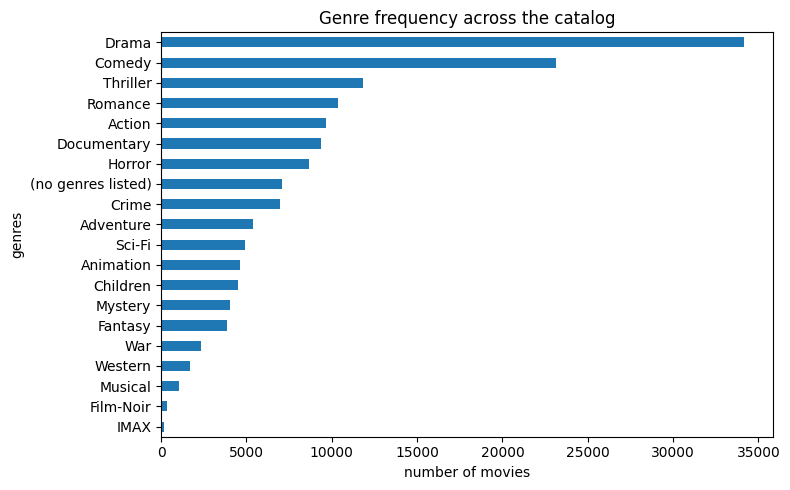

In [8]:
genre_counts = movies['genres'].str.split('|').explode().value_counts()
print(genre_counts)

plt.figure(figsize=(8,5))
genre_counts.plot(kind='barh'); plt.gca().invert_yaxis()
plt.title('Genre frequency across the catalog'); plt.xlabel('number of movies')
plt.tight_layout()
plt.savefig(os.path.join(FIG, 'eda_genre_distribution.png'), dpi=120); plt.show()

7. tmdbId availability

In [9]:
n_total     = len(links)
n_with_tmdb = int(links['tmdbId'].notna().sum())
n_missing   = int(links['tmdbId'].isna().sum())
print(f"movies total       : {n_total:,}")
print(f"WITH tmdbId        : {n_with_tmdb:,}  ({n_with_tmdb/n_total*100:.2f}%)   <- fetch targets")
print(f"WITHOUT tmdbId (NaN): {n_missing:,}  ({n_missing/n_total*100:.2f}%)   <- no overview possible")

movies total       : 87,585
WITH tmdbId        : 87,461  (99.86%)   <- fetch targets
WITHOUT tmdbId (NaN): 124  (0.14%)   <- no overview possible


TMDB endpoint exploration

1. Set up the key and a raw fetch helper

In [10]:
from google.colab import userdata
import requests
TMDB_API_KEY = userdata.get('TMDB_API_KEY')

def fetch_movie_raw(tmdb_id):
    url = f"https://api.themoviedb.org/3/movie/{int(tmdb_id)}"
    params = {"api_key": TMDB_API_KEY, "append_to_response": "credits"}
    r = requests.get(url, params=params, timeout=10)
    return r.status_code, r.json()

status, movie = fetch_movie_raw(862)   # 862 = Toy Story
print("status:", status)
print("top-level keys:", sorted(movie.keys()))

status: 200
top-level keys: ['adult', 'backdrop_path', 'belongs_to_collection', 'budget', 'credits', 'genres', 'homepage', 'id', 'imdb_id', 'origin_country', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'softcore', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']


2. Inspect the specific fields we care about

In [11]:
print("title       :", movie.get('title'))
print("overview    :", (movie.get('overview') or '')[:100], "...")
print("runtime     :", movie.get('runtime'))
print("release_date:", movie.get('release_date'))
print("genres      :", [g['name'] for g in movie.get('genres', [])])
print("cast[:5]    :", [c['name'] for c in movie.get('credits', {}).get('cast', [])[:5]])
directors = [c['name'] for c in movie.get('credits', {}).get('crew', []) if c.get('job') == 'Director']
print("director(s) :", directors)

title       : Toy Story
overview    : Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto  ...
runtime     : 81
release_date: 1995-11-22
genres      : ['Family', 'Comedy', 'Animation', 'Adventure']
cast[:5]    : ['Tom Hanks', 'Tim Allen', 'Don Rickles', 'Jim Varney', 'Wallace Shawn']
director(s) : ['John Lasseter']


3. The extraction helper

In [12]:
def extract_fields(m):
    """Turn TMDB's nested movie JSON (with credits) into the flat record we store."""
    crew = m.get('credits', {}).get('crew', [])
    cast = m.get('credits', {}).get('cast', [])
    director = next((c['name'] for c in crew if c.get('job') == 'Director'), None)
    rd   = m.get('release_date') or ''
    year = int(rd[:4]) if rd[:4].isdigit() else None
    return {
        'tmdb_id' : m.get('id'),
        'title'   : m.get('title'),
        'overview': m.get('overview') or '',
        'genres'  : [g['name'] for g in m.get('genres', [])],
        'runtime' : m.get('runtime'),
        'year'    : year,
        'director': director,
        'cast'    : [c['name'] for c in cast[:5]],
    }

for tid in [862, 550]:   # Toy Story, Fight Club
    _, m = fetch_movie_raw(tid)
    print(extract_fields(m), "\n")

{'tmdb_id': 862, 'title': 'Toy Story', 'overview': "Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.", 'genres': ['Family', 'Comedy', 'Animation', 'Adventure'], 'runtime': 81, 'year': 1995, 'director': 'John Lasseter', 'cast': ['Tom Hanks', 'Tim Allen', 'Don Rickles', 'Jim Varney', 'Wallace Shawn']} 

{'tmdb_id': 550, 'title': 'Fight Club', 'overview': 'A ticking-time-bomb insomniac and a slippery soap salesman channel primal male aggression into a shocking new form of therapy. Their concept catches on, with underground "fight clubs" forming in every town, until an eccentric gets in the way and ignites an out-of-control spiral toward oblivion.', 'genres': ['Drama', 'Thriller'], 'runtime': 139, 'year': 1999, 'director': 'David Fincher',

4. Measure per-call latency

In [13]:
sample_ids = [862, 8844, 15602, 550, 13]
t0 = time.time()
for tid in sample_ids:
    fetch_movie_raw(tid)
elapsed = time.time() - t0
print(f"{len(sample_ids)} sequential calls: {elapsed:.2f}s  ->  ~{elapsed/len(sample_ids):.2f}s/call")
print(f"est. sequential fetch of {n_with_tmdb:,} movies: ~{n_with_tmdb*(elapsed/len(sample_ids))/3600:.1f} h")

5 sequential calls: 0.30s  ->  ~0.06s/call
est. sequential fetch of 87,461 movies: ~1.5 h
